**SWE-Bench charged-token cost (Codex / gpt-5.6-luna).** Every point
charges session tokens plus document-replay tokens. AgentTX causal
never replays independent documents; optimistic checkpoint and
whole-branch abort replay them on all 300 tasks. Scale bins are
terciles of the clean-solve cost (100 tasks; cuts at 617k and 1.27M).
(a) median charged tokens; (b) replay tax only; (c) paired charged
ratio versus the clean solve; (d) charged-token CDF. Line styles match
the earlier FAST figures.


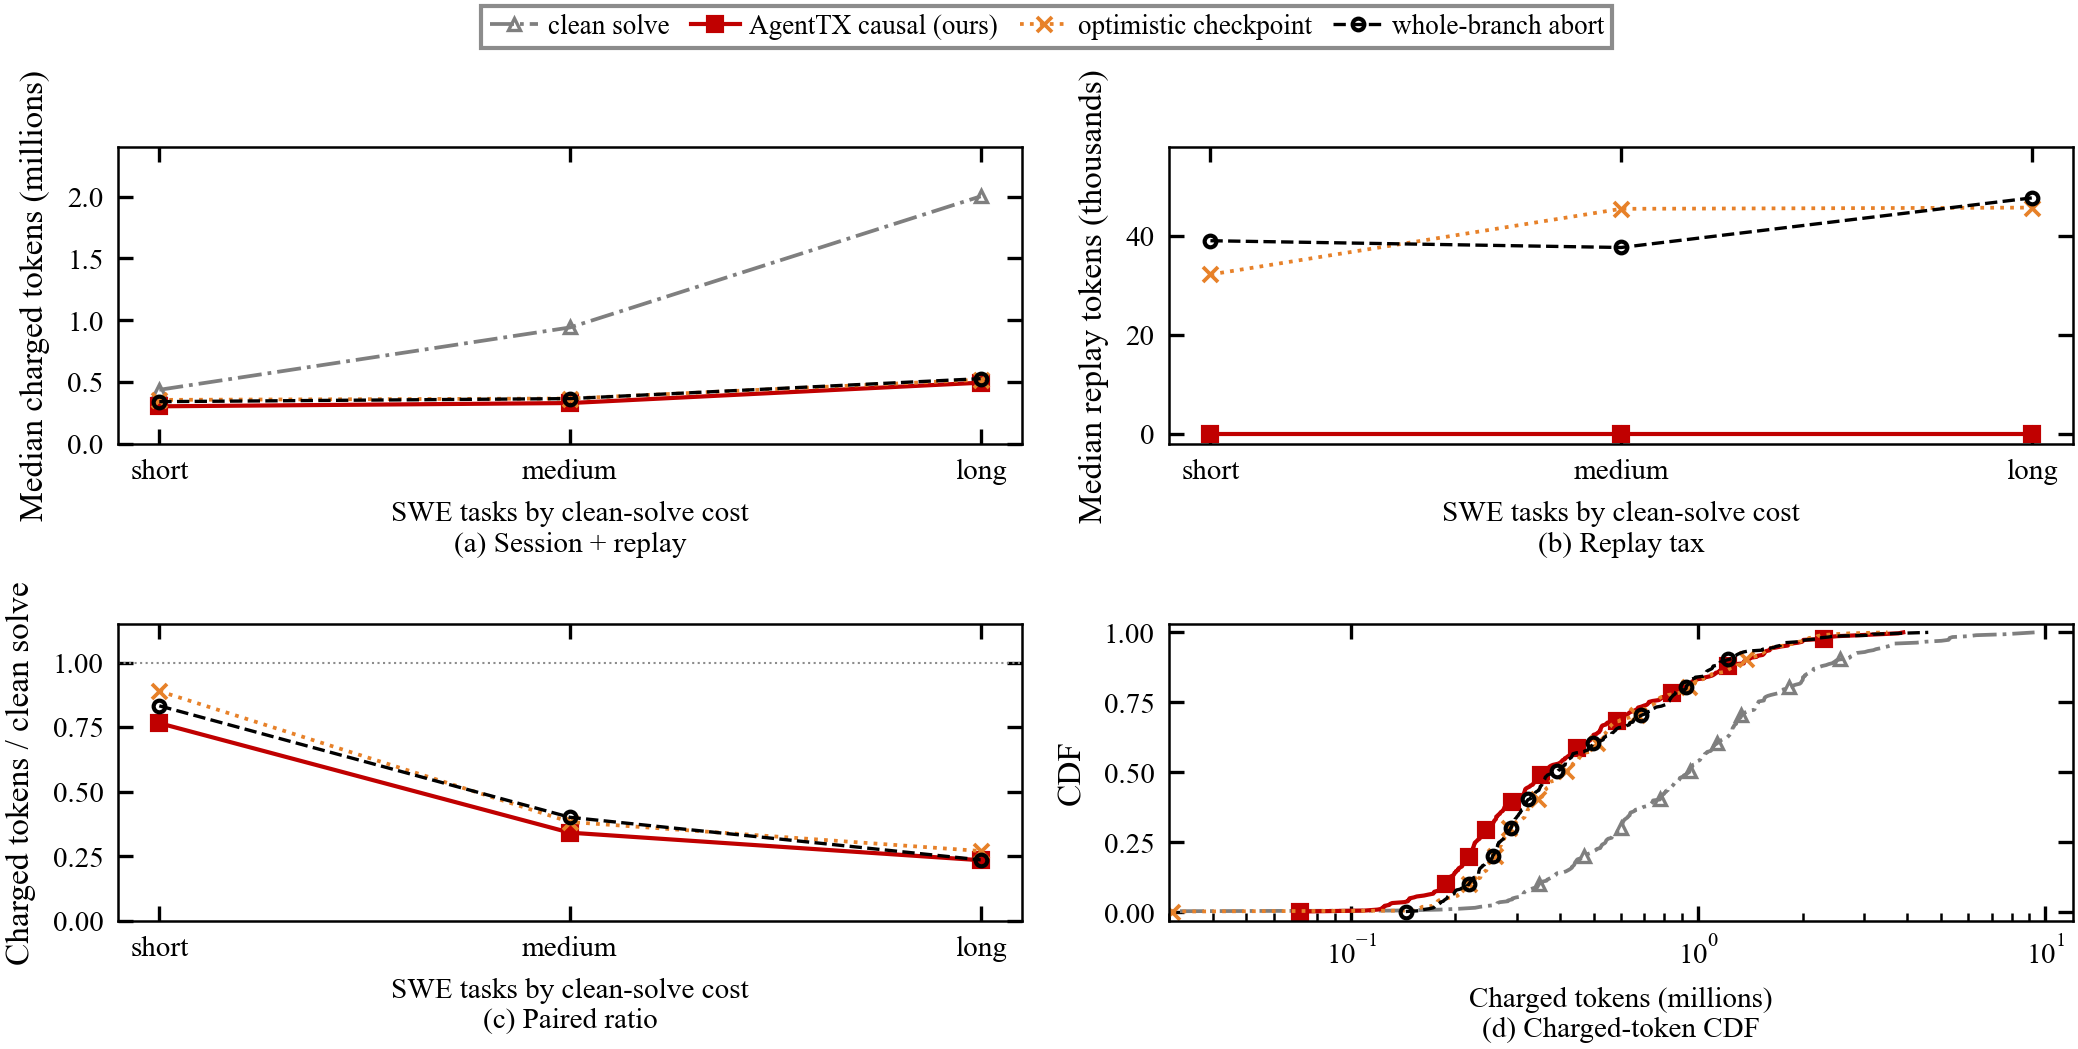

In [1]:
# ipython -c "%run plot_swe_tokens.ipynb"
# FAST/USENIX line-plot conventions: white panels, boxed top legend,
# red solid squares = ours. Token y-values are charged = session + replay.
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd
from pathlib import Path

try:
    get_ipython()
except NameError:
    matplotlib.use("Agg")

STANDARD_WIDTH = 17.8


def cm_to_inch(value):
    return value / 2.54


plt.rcParams.update(plt.rcParamsDefault)
matplotlib.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Nimbus Roman", "Times New Roman", "Times"]
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.linewidth"] = 0.6
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.edgecolor"] = "0.55"
plt.rcParams["legend.framealpha"] = 1.0
plt.rcParams["legend.fancybox"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

STYLES = {
    "no_fault": dict(
        color="#7f7f7f",
        marker="^",
        linestyle="-.",
        linewidth=0.9,
        markersize=3.0,
        markerfacecolor="none",
        markeredgewidth=0.8,
    ),
    "causal": dict(color="#c00000", marker="s", linestyle="-", linewidth=1.0, markersize=3.2),
    "temporal_checkpoint": dict(
        color="#e78129",
        marker="x",
        linestyle=":",
        linewidth=0.9,
        markersize=3.6,
        markeredgewidth=0.9,
    ),
    "whole_branch_abort": dict(
        color="black",
        marker="o",
        linestyle="--",
        linewidth=0.8,
        markersize=2.8,
        markerfacecolor="none",
    ),
}
LABELS = {
    "no_fault": "clean solve",
    "causal": "AgentTX causal (ours)",
    "temporal_checkpoint": "optimistic checkpoint",
    "whole_branch_abort": "whole-branch abort",
}
MODES = list(STYLES)

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "motivation" else cwd
FIGDIR = ROOT / "motivation"
PAPER = ROOT / "paper" / "img"
FIGDIR.mkdir(parents=True, exist_ok=True)
PAPER.mkdir(parents=True, exist_ok=True)
CSV = ROOT / "experiments" / "results" / "codex_7mode_full_r1_parallel_20260903" / "swe_official_tasks_raw.csv"

df = pd.read_csv(CSV)
df["total_tokens"] = pd.to_numeric(df["total_tokens"], errors="coerce").fillna(0.0)
df["doc_replay_tokens"] = pd.to_numeric(df["doc_replay_tokens"], errors="coerce").fillna(0.0)
df["charged"] = df["total_tokens"] + df["doc_replay_tokens"]

wide = (
    df.pivot_table(index="task", columns="mode", values="charged", aggfunc="first")
    .sort_values("no_fault")
    .copy()
)
replay = (
    df.pivot_table(index="task", columns="mode", values="doc_replay_tokens", aggfunc="first")
    .reindex(wide.index)
)
wide["scale"] = pd.qcut(wide["no_fault"], 3, labels=["short", "medium", "long"])
SCALE_LABELS = ["short", "medium", "long"]
sx = np.arange(len(SCALE_LABELS))


def ecdf(values):
    values = np.asarray(values, dtype=float)
    values = values[values > 0]
    x = np.sort(values)
    y = np.arange(1, x.size + 1) / x.size
    return x, y


fig = plt.figure(dpi=300, figsize=(cm_to_inch(STANDARD_WIDTH), cm_to_inch(8.8)))
handles = []

ax = plt.subplot(2, 2, 1)
for mode in MODES:
    ys = [wide.loc[wide["scale"] == scale, mode].median() / 1e6 for scale in SCALE_LABELS]
    handle, = ax.plot(sx, ys, **STYLES[mode], label=LABELS[mode])
    handles.append(handle)
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(0, 2.4)
ax.set_ylabel("Median charged tokens (millions)", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(a) Session + replay", fontsize=7)

ax = plt.subplot(2, 2, 2)
for mode in MODES:
    ys = [replay.loc[wide["scale"] == scale, mode].median() / 1e3 for scale in SCALE_LABELS]
    ax.plot(sx, ys, **STYLES[mode])
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(-2, 58)
ax.set_ylabel("Median replay tokens (thousands)", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(b) Replay tax", fontsize=7)

ax = plt.subplot(2, 2, 3)
ax.axhline(1.0, color="0.55", linewidth=0.5, linestyle=":")
for mode in ("causal", "temporal_checkpoint", "whole_branch_abort"):
    ys = [
        (wide.loc[wide["scale"] == scale, mode] / wide.loc[wide["scale"] == scale, "no_fault"]).median()
        for scale in SCALE_LABELS
    ]
    ax.plot(sx, ys, **STYLES[mode])
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Charged tokens / clean solve", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(c) Paired ratio", fontsize=7)

ax = plt.subplot(2, 2, 4)
for mode in MODES:
    x, y = ecdf(df.loc[df["mode"] == mode, "charged"].to_numpy(dtype=float) / 1e6)
    ax.plot(x, y, markevery=max(len(x) // 10, 1), **STYLES[mode])
ax.set_xscale("log")
ax.set_xlim(0.03, 12)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
ax.set_ylim(-0.03, 1.03)
ax.set_ylabel("CDF", fontsize=8)
ax.set_xlabel("Charged tokens (millions)\n(d) Charged-token CDF", fontsize=7)

for axis in fig.axes:
    axis.tick_params(axis="both", labelsize=7, direction="in", top=True, right=True)

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.035),
    ncol=4,
    fontsize=6.5,
    columnspacing=0.8,
    handlelength=1.8,
    handletextpad=0.35,
    borderpad=0.3,
)
plt.tight_layout(pad=0.6, h_pad=1.6, w_pad=1.2, rect=[0.0, 0.0, 1.0, 0.91])
for dest in (FIGDIR, PAPER):
    fig.savefig(dest / "FIG-SWE-Tokens.pdf", bbox_inches="tight", pad_inches=0.02)
    fig.savefig(dest / "FIG-SWE-Token-Tasks.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
if matplotlib.get_backend().lower() != "agg":
    plt.show()

print(f"loaded {CSV}")
print("charged = session + replay")
for mode in MODES:
    rows = df[df["mode"] == mode]
    print(
        f"{LABELS[mode]:24s}: charged_p50={rows['charged'].median()/1e3:7.1f}k  "
        f"session_p50={rows['total_tokens'].median()/1e3:7.1f}k  "
        f"replay_p50={rows['doc_replay_tokens'].median()/1e3:6.1f}k  "
        f"replay_mean={rows['doc_replay_tokens'].mean()/1e3:6.1f}k"
    )
print("charged median by scale (millions):")
print((wide.groupby("scale", observed=False)[MODES].median() / 1e6).round(3).to_string())
for mode in ("causal", "temporal_checkpoint", "whole_branch_abort"):
    ratio = (wide[mode] / wide["no_fault"]).replace([np.inf, -np.inf], np.nan).dropna()
    print(
        f"ratio {LABELS[mode]:24s} / clean: "
        f"p50={ratio.median():.3f}  cheaper={(ratio < 1).mean():.1%}"
    )
